# Assignment_10_Multimodal_Fake_News

Design a model to detect Fake News from Multimodal data.


## Aim
Design a multimodal fake-news detection model using text and image information.

**Dataset:** Fakeddit multimodal data.

This notebook expects a Fakeddit TSV containing at least:
- `clean_title`
- `image_url`
- `2_way_label`

It uses TF-IDF for text, MobileNetV2 for image features, concatenates both feature vectors, and trains Logistic Regression.

**Important:** use a manageable sample in Colab. The notebook downloads only the selected images.


In [ ]:
# Colab already includes NumPy, Pandas, PyTorch and scikit-learn.
import os, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm

RESULT_DIR="/content/results"
IMAGE_DIR="/content/fakeddit_images"
os.makedirs(RESULT_DIR,exist_ok=True)
os.makedirs(IMAGE_DIR,exist_ok=True)


In [ ]:
# Upload Fakeddit multimodal_train.tsv
from google.colab import files

uploaded=files.upload()
TSV_PATH=next(iter(uploaded.keys()))
df=pd.read_csv(TSV_PATH,sep="\t")

print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
display(df.head())


Saving multimodal_train.tsv to multimodal_train (1).tsv
Shape: (564000, 16)
Columns: ['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


In [ ]:
# Select required fields and create a manageable balanced sample.
required=["clean_title","image_url","2_way_label"]
missing=[c for c in required if c not in df.columns]
if missing:
    raise ValueError("Missing columns: "+str(missing))

df=df[required].dropna()
df=df[df["clean_title"].str.strip()!=""]
df=df[df["image_url"].str.startswith(("http://","https://"))]

per_class=min(150, int(df["2_way_label"].value_counts().min()))
parts=[]
for label in sorted(df["2_way_label"].unique()):
    parts.append(df[df["2_way_label"]==label].sample(per_class,random_state=42))

df=pd.concat(parts).sample(frac=1,random_state=42).reset_index(drop=True)
print("Working sample:",df.shape)
display(df["2_way_label"].value_counts())


Working sample: (300, 3)


,count
2_way_label,
1,150
0,150


In [ ]:
# Download images.
valid=[]
for i,row in tqdm(df.iterrows(),total=len(df)):
    path=os.path.join(IMAGE_DIR,f"{i}.jpg")
    try:
        r=requests.get(row["image_url"],timeout=8,
                       headers={"User-Agent":"Mozilla/5.0"})
        r.raise_for_status()
        img=Image.open(BytesIO(r.content)).convert("RGB")
        img.save(path,"JPEG")
        valid.append([i,row["clean_title"],path,int(row["2_way_label"])])
    except Exception:
        pass

data=pd.DataFrame(valid,columns=["id","text","image_path","label"])
print("Usable samples:",len(data))
display(data["label"].value_counts())


  0%|          | 0/300 [00:00<?, ?it/s]

Usable samples: 286


,count
label,
0,146
1,140


In [ ]:
# Text features: TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

train_df,test_df=train_test_split(
    data,test_size=.2,random_state=42,stratify=data["label"])

vectorizer=TfidfVectorizer(
    max_features=500,stop_words="english",ngram_range=(1,2))

X_text_train=vectorizer.fit_transform(train_df["text"]).toarray()
X_text_test=vectorizer.transform(test_df["text"]).toarray()

print("Text feature shape:",X_text_train.shape)


Text feature shape: (228, 500)


In [ ]:
# Image features: pretrained MobileNetV2
import torch
from torchvision import models

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights=models.MobileNet_V2_Weights.DEFAULT
cnn=models.mobilenet_v2(weights=weights)
cnn.classifier=torch.nn.Identity()
cnn=cnn.to(device).eval()
preprocess=weights.transforms()

def image_features(paths,batch_size=16):
    all_features=[]
    good=[]
    for start in range(0,len(paths),batch_size):
        batch_paths=paths[start:start+batch_size]
        imgs=[]
        good_batch=[]
        for p in batch_paths:
            try:
                imgs.append(preprocess(Image.open(p).convert("RGB")))
                good_batch.append(p)
            except Exception:
                pass
        if not imgs:
            continue
        batch=torch.stack(imgs).to(device)
        with torch.no_grad():
            f=cnn(batch).cpu().numpy()
        all_features.append(f)
        good.extend(good_batch)
    return np.vstack(all_features),good

X_img_train,paths_train=image_features(train_df["image_path"].tolist())
X_img_test,paths_test=image_features(test_df["image_path"].tolist())

print("Image feature shape:",X_img_train.shape)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


Image feature shape: (228, 1280)


In [ ]:
# Match text rows to successful image downloads and fuse features.
train_lookup=train_df.set_index("image_path")
test_lookup=test_df.set_index("image_path")

train_idx=[train_df.index[train_df["image_path"]==p][0] for p in paths_train]
test_idx=[test_df.index[test_df["image_path"]==p][0] for p in paths_test]

X_text_train_f=vectorizer.transform(train_df.loc[train_idx,"text"]).toarray()
X_text_test_f=vectorizer.transform(test_df.loc[test_idx,"text"]).toarray()

y_train=train_df.loc[train_idx,"label"].to_numpy()
y_test=test_df.loc[test_idx,"label"].to_numpy()

X_train=np.hstack([X_text_train_f,X_img_train])
X_test=np.hstack([X_text_test_f,X_img_test])

print("Fused train shape:",X_train.shape)
print("Fused test shape:",X_test.shape)


Fused train shape: (228, 1780)
Fused test shape: (58, 1780)


Accuracy: 0.6724137931034483

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.63      0.67        30
           1       0.65      0.71      0.68        28

    accuracy                           0.67        58
   macro avg       0.67      0.67      0.67        58
weighted avg       0.68      0.67      0.67        58



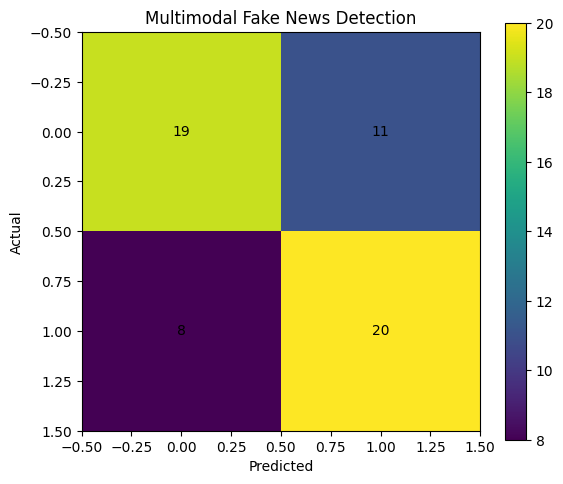

In [ ]:
# Train and evaluate the multimodal classifier.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
pred=model.predict(X_test)

accuracy=accuracy_score(y_test,pred)
print("Accuracy:",accuracy)
print("\nClassification Report:\n",classification_report(y_test,pred))

report=pd.DataFrame(classification_report(y_test,pred,output_dict=True)).T
report.to_csv(f"{RESULT_DIR}/fake_news_classification_report.csv")

cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Multimodal Fake News Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/fake_news_confusion_matrix.png",dpi=150)
plt.show()

pd.DataFrame({"Metric":["Accuracy"],"Value":[accuracy]}).to_csv(
    f"{RESULT_DIR}/accuracy.csv",index=False)


In [ ]:
# Package and download all Assignment 10 results.
import shutil
shutil.make_archive("/content/Assignment_10_Results","zip",RESULT_DIR)

from google.colab import files
files.download("/content/Assignment_10_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>